# Figure 3

## Mice stay more central, move slower and orient themselves more toward the objects as they approach the screen when faced with obstructed objects.

For reference, here is the full figure

![dual_occlusion](final_figures/dual_occlusion.jpg) 

and corresponding supplemental figure

![Supplemental dual_occlusion](final_figures/supp_dual_occlusion.jpg)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-15 13:16:03,860][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-05-15 13:16:04,036][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Example trajectories (Pheasant_2024-08-15_2)

In [5]:
# Load dataset and box positions
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "reward",
        "x",
        "y",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "trial_tortuosity",
        "trial_init_x",
        "trial_init_y",
    ],
)
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

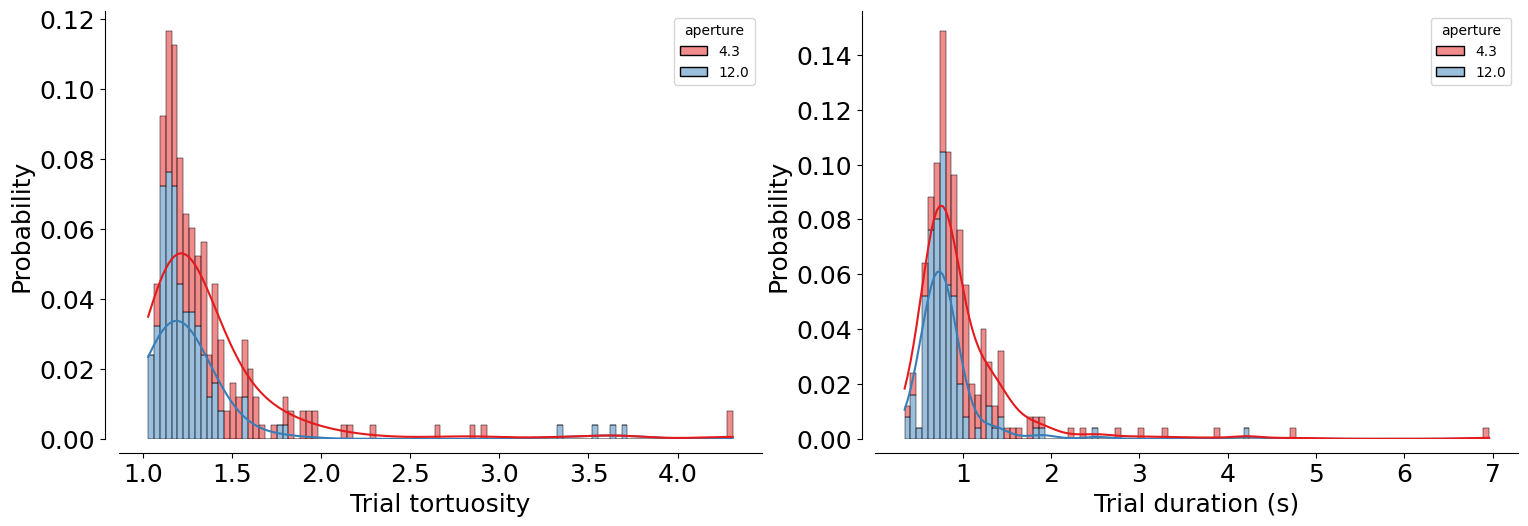

In [6]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(df, ax=ax, log_scale=False)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

sns.despine(offset=10)

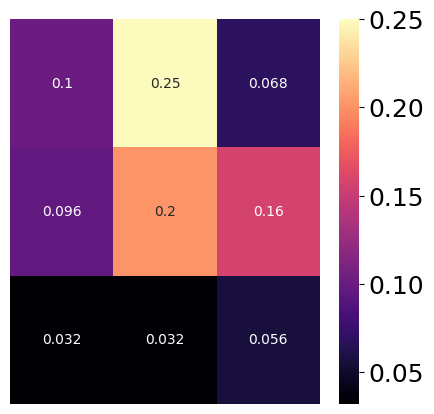

In [7]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = (
        df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    )
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
# plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.25,
)

ax.set_xticks([])
ax.set_yticks([])

fig.savefig(save_fig_path + "figure3_example_initial_position_heatmap.svg", dpi=300, bbox_inches="tight", transparent=True)

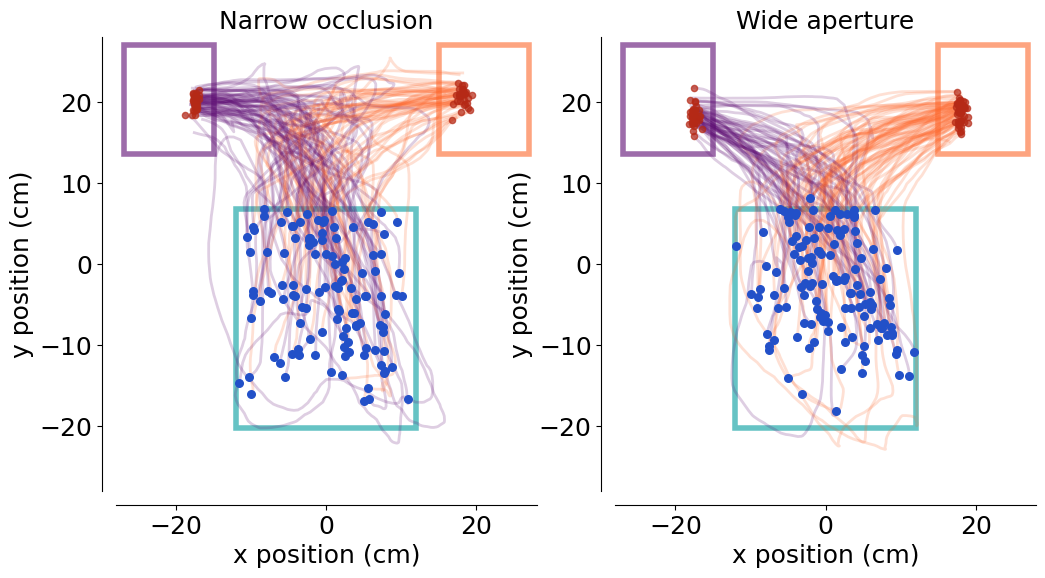

In [7]:
df = df[df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

ax = plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)

ax[0].set_title("Narrow occlusion")
ax[1].set_title("Wide aperture")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_example_session_trajectory_plot_dual_occluder.svg", transparent=True)

## Change of mind trials

In [8]:
from vr4mice.analysis.analysis import get_rewarded
j_shaped["trial_rewarded"] = get_rewarded(j_shaped)

In [9]:
first_y = j_shaped.groupby(["dataset", "trial"])["trial_init_y"].transform("first")
min_y = j_shaped.groupby(["dataset", "trial"])["y"].transform(lambda x: x.min())

j_shaped["is_greater"] = first_y > min_y

In [10]:
high_treshold = j_shaped[(j_shaped.is_greater == 0)].trial_tortuosity.quantile([0.9]).iloc[0]
low_threshold = j_shaped[(j_shaped.is_greater == 0)].trial_tortuosity.quantile([0.1]).iloc[0]

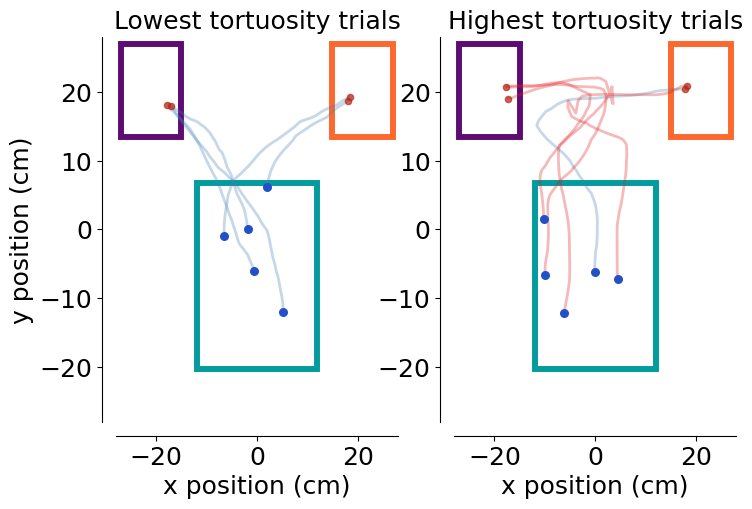

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

for trial_idx in j_shaped[(j_shaped.trial_tortuosity < low_threshold) & (j_shaped.is_greater == 0)].trial.unique()[:5]:
    if j_shaped[(j_shaped.trial == trial_idx)].aperture.iloc[0] == 4.3:
        color = plotting.colors_aperture[0]
    else: 
        color = plotting.colors_aperture[1]
    ax[0] = plotting.plot_session(
            df=j_shaped[(j_shaped.trial == trial_idx)],
            box_df=box_df,
            per_side=False,
            ax=ax[0],
            color = color
        )

ax[0].set_title("Lowest tortuosity trials")
    
for trial_idx in j_shaped[(j_shaped.trial_tortuosity > high_treshold) & (j_shaped.is_greater == 0)].trial.unique()[:5]:
    if j_shaped[(j_shaped.trial == trial_idx)].aperture.iloc[0] == 4.3:
        color = plotting.colors_aperture[0]
    else: 
        color = plotting.colors_aperture[1]
    ax[1] = plotting.plot_session(
            df=j_shaped[(j_shaped.trial == trial_idx)],
            box_df=box_df,
            ax=ax[1],
            color=color
        )

ax[1].set_title("Highest tortuosity trials")
ax[1].set_ylabel("")
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_change_of_mind.svg", transparent=True)

In [17]:
# get the percentage of narrow / wide in each group
low_tortuosity = j_shaped[(j_shaped.trial_tortuosity < low_threshold) & (j_shaped.is_greater == 0)]
high_tortuosity = j_shaped[(j_shaped.trial_tortuosity > high_treshold) & (j_shaped.is_greater == 0)]
print("Low tortuosity group:")
print(low_tortuosity.aperture.value_counts(normalize=True))
print("\nHigh tortuosity group:")
print(high_tortuosity.aperture.value_counts(normalize=True))

Low tortuosity group:
aperture
12.0    0.732125
4.3     0.267875
Name: proportion, dtype: float64

High tortuosity group:
aperture
4.3     0.870103
12.0    0.129897
Name: proportion, dtype: float64


## Combined sessions analysis
Fetching the data:

In [12]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)

# Create list of included datasets
sessions_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str[0]

In [13]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(10, 43)

In [14]:
trial_df.mouse_name.unique()

array(['31726', '31728', 'J729', 'J731', 'Jacana', 'Kiwi', 'Lemming',
       'Nightingale', 'Oribi', 'Pheasant'], dtype=object)

In [15]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
31726          4
31728          3
J729           6
J731           1
Jacana         5
Kiwi           5
Lemming        4
Nightingale    5
Oribi          5
Pheasant       5
Name: dataset, dtype: int64

In [25]:
df_init = pd.concat(DataFrame().get_data(
        key={"dataset": mouse},
        columns=[
            "dataset",
            "trial",
            "trial_init_x",
            "trial_init_y",
            "trial_left_choice",
            "aperture",
            "y",
            "trial_tortuosity", # for change of mind analysis
        ],
    ) for mouse in sessions_list)

### Initial position analysis across all sessions

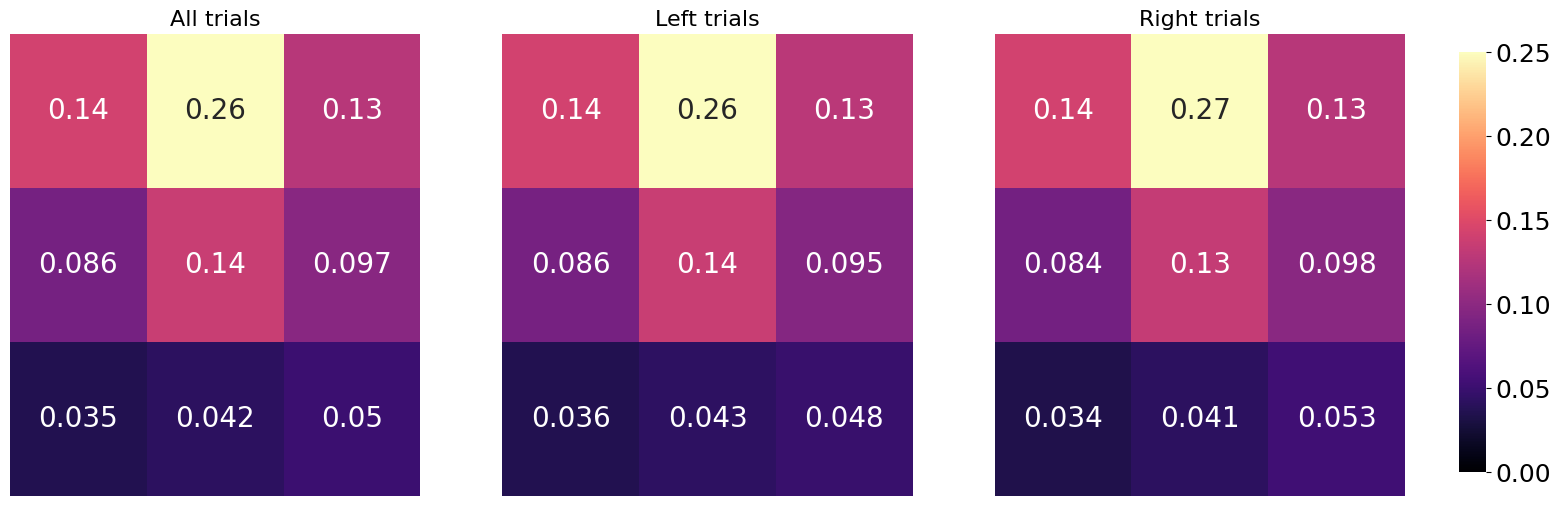

In [19]:
apertures = df_init.aperture.unique()
choices = sorted(df_init.trial_left_choice.unique())
hist_dict = {c: [] for c in choices}
session_hist = {c: {} for c in choices}
all_sessions_hists = []

for session in df_init.dataset.unique():
    session_df = df_init[df_init.dataset == session]
    
    # Calculate Full Histogram for this session
    full_hist = plotting.plot_init_position_histogram(
        session_df, box_df, ax=None, bins=3, is_density=False
    )
    n_total = session_df.groupby("trial").trial_init_x.first().count()
    all_sessions_hists.append(full_hist / n_total)
    
    # Calculate conditioned Histograms for this session
    for ch in choices:
        subset = session_df[(session_df.trial_left_choice == ch)]
        if not subset.empty:
            h = plotting.plot_init_position_histogram(
                subset, box_df, ax=None, bins=3, is_density=False
            )
            n_cond = subset.groupby("trial").trial_init_x.first().count()
            h_norm = h / n_cond
            hist_dict[ch].append(h_norm)
            session_hist[ch][session] = h_norm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax_full, ax_left, ax_right = axes
VMAX = 0.25
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

full_mean = np.mean(all_sessions_hists, axis=0)
sns.heatmap(
    np.flip(full_mean, axis=1).T,
    cmap="magma",
    annot=True,
    annot_kws={"size": 20},
    vmax=VMAX,
    vmin=0,
    ax=ax_full,
    cbar=False,
    )
ax_full.set_title("All trials", fontsize=16)

def _choice_label(choice_val):
    if choice_val == 1:
        return "Left"
    if choice_val == 0:
        return "Right"
    return f"Choice {choice_val}"

choice_axes = {}
if 1 in choices:
    choice_axes[1] = ax_left
if 0 in choices:
    choice_axes[0] = ax_right

remaining = [c for c in choices if c not in choice_axes]
if remaining and ax_left not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_left
if remaining and ax_right not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_right

plot_choices = [ch for ch in [1, 0] if ch in choice_axes]
if not plot_choices:
    plot_choices = list(choice_axes.keys())

for idx, ch in enumerate(plot_choices):
    ax = choice_axes[ch]
    if hist_dict[ch]:
        cond_mean = np.mean(hist_dict[ch], axis=0)
        sns.heatmap(
            np.flip(cond_mean, axis=1).T,
            cmap="magma",
            annot=True,
            annot_kws={"size": 20},
            vmax=VMAX,
            vmin=0,
            ax=ax,
            cbar=(idx == len(plot_choices) - 1),
            cbar_ax=(cbar_ax if idx == len(plot_choices) - 1 else None),
        )
    ax.set_title(f"{_choice_label(ch)} trials", fontsize=16)

# Formatting cleanup
for ax in [ax_full, ax_left, ax_right]:
    ax.set_xticks([])
    ax.set_yticks([])

#plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3, hspace=0.3)
fig.savefig(save_fig_path + "figure3_initial_position_heatmaps.svg", dpi=300, bbox_inches="tight", transparent=True)

In [20]:
# Per-bin significance tests between choices
ch_order = sorted(choices)
sig_rows = []

def collect_choice_hist(c_val):
    return session_hist[c_val]

# Between choices
if len(ch_order) >= 2:
    shared_sessions = set(collect_choice_hist(ch_order[0]).keys()).intersection(
        collect_choice_hist(ch_order[1]).keys()
    )
    if shared_sessions:
        example_hist = collect_choice_hist(ch_order[0])[next(iter(shared_sessions))]
        for r, c in np.ndindex(example_hist.shape):
            vals_a = [collect_choice_hist(ch_order[0])[s][r, c] for s in shared_sessions]
            vals_b = [collect_choice_hist(ch_order[1])[s][r, c] for s in shared_sessions]
            if len(vals_a) < 2 or len(vals_b) < 2:
                continue
            t = ttest_rel(vals_a, vals_b)
            sig_rows.append(
                {
                    "comparison": "choice",
                    "level_a": ch_order[0],
                    "level_b": ch_order[1],
                    "bin_row": r,
                    "bin_col": c,
                    "p_value": t.pvalue,
                    "t_stat": t.statistic,
                    "n_sessions": len(vals_a),
                }
            )

sig_df = pd.DataFrame(sig_rows)
if not sig_df.empty:
    sig_df["p_value_corr"] = stats.false_discovery_control(sig_df.p_value)
    sig_df["significant"] = sig_df.p_value_corr < 0.05
    
sig_df

,comparison,level_a,level_b,bin_row,bin_col,p_value,t_stat,n_sessions,p_value_corr,significant
0,choice,0.0,1.0,0,0,0.654021,-0.451403,43,0.895116,False
1,choice,0.0,1.0,0,1,0.727688,-0.350537,43,0.895116,False
2,choice,0.0,1.0,0,2,0.961987,-0.047945,43,0.961987,False
3,choice,0.0,1.0,1,0,0.729751,-0.347768,43,0.895116,False
4,choice,0.0,1.0,1,1,0.690798,-0.400527,43,0.895116,False
5,choice,0.0,1.0,1,2,0.365667,0.914515,43,0.895116,False
6,choice,0.0,1.0,2,0,0.383172,0.881299,43,0.895116,False
7,choice,0.0,1.0,2,1,0.676427,0.420275,43,0.895116,False
8,choice,0.0,1.0,2,2,0.795658,-0.260621,43,0.895116,False


### Change of mind stats

In [26]:
first_y = df_init.groupby(["dataset", "trial"])["trial_init_y"].transform("first")
min_y = df_init.groupby(["dataset", "trial"])["y"].transform(lambda x: x.min())

df_init["is_greater"] = first_y > min_y

In [27]:
high_threshold = df_init[(df_init.is_greater == 0)].trial_tortuosity.quantile([0.9]).iloc[0]
low_threshold = df_init[(df_init.is_greater == 0)].trial_tortuosity.quantile([0.1]).iloc[0]

In [36]:
# merge low/high with trial_df
merged_df = trial_df.merge(
    df_init[["dataset", "trial", "trial_tortuosity", "is_greater"]],
    on=["dataset", "trial"],
    how="left",
)

In [37]:
# get the percentage of narrow / wide in each group
low_tortuosity = merged_df[(merged_df.trial_tortuosity_x < low_threshold) & (merged_df.is_greater == 0)]
high_tortuosity = merged_df[(merged_df.trial_tortuosity_x > high_threshold) & (merged_df.is_greater == 0)]
print("Low tortuosity group:")
print(low_tortuosity.aperture.value_counts(normalize=True))
print("\nHigh tortuosity group:")
print(high_tortuosity.aperture.value_counts(normalize=True))

Low tortuosity group:
aperture
12.0    0.904007
4.3     0.095993
Name: proportion, dtype: float64

High tortuosity group:
aperture
4.3     0.865924
12.0    0.134076
Name: proportion, dtype: float64


In [38]:
# get the percentage of rewarded trials in each group
print("\nLow tortuosity group - Rewarded:")
print(low_tortuosity.trial_rewarded.value_counts(normalize=True))
print("\nHigh tortuosity group - Rewarded:")
print(high_tortuosity.trial_rewarded.value_counts(normalize=True))


Low tortuosity group - Rewarded:
trial_rewarded
1.0    0.816316
0.0    0.183684
Name: proportion, dtype: float64

High tortuosity group - Rewarded:
trial_rewarded
1.0    0.683245
0.0    0.316755
Name: proportion, dtype: float64


### Rate plots

In [21]:
trial_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

4.3: mean=0.763 ± 0.014
12.0-4.3: TtestResult(statistic=5.6137738198471006, pvalue=1.4247895544665545e-06, df=42)
12.0: mean=0.864 ± 0.010


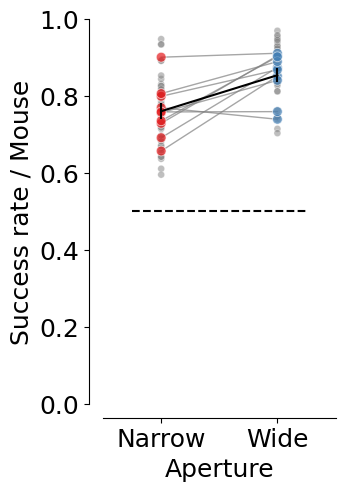

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure3_trial_reward.svg", transparent=True)

4.3: mean=0.763 ± 0.014
12.0-4.3: TtestResult(statistic=6.980682819350614, pvalue=1.5489501656918376e-08, df=42)
12.0: mean=0.864 ± 0.010


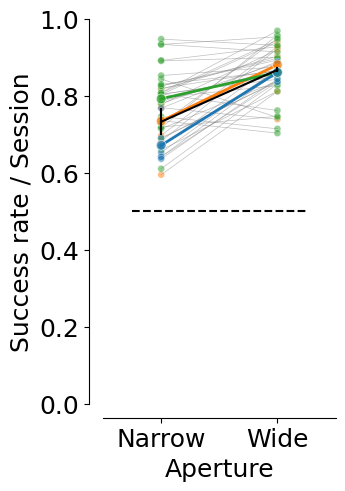

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_lab=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])

sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure3_trial_reward_per_lab.svg", transparent=True)


wide aperture mean:  0.5029833413299016 std:  0.03979605091536686
narrow aperture mean:  0.49701665867009837 std:  0.03979605091536686


TtestResult(statistic=0.4858336726690031, pvalue=0.6296102127782549, df=42)

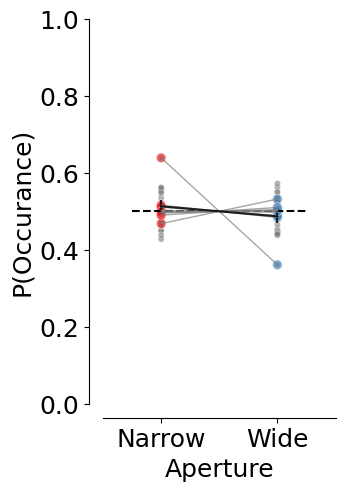

In [24]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Aperture")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure3_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide aperture mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow aperture mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

4.3: mean=0.158 ± 0.042
12.0-4.3: TtestResult(statistic=-2.0476532990655105, pvalue=0.04688129737509803, df=42)
12.0: mean=0.052 ± 0.035
12.0 vs chance 0: t=1.07, p=0.311
4.3 vs chance 0: t=2.09, p=0.066


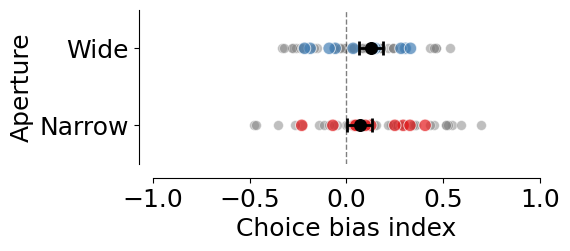

In [25]:
# Bias index for choice preference
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_choice_bias.svg", transparent=True)

4.3: mean=0.158 ± 0.042
12.0-4.3: TtestResult(statistic=-1.897565129511044, pvalue=0.06464180107093387, df=42)
12.0: mean=0.052 ± 0.035
4.3 vs chance 0: t=3.74, p=0.001
12.0 vs chance 0: t=1.46, p=0.151


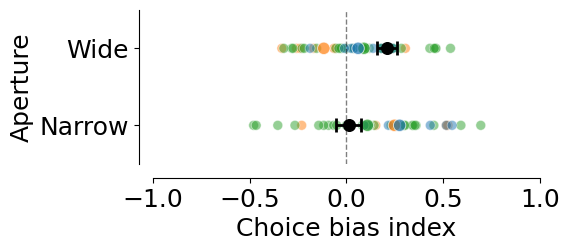

In [26]:
# Bias index for choice preference per lab
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    per_lab=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_choice_bias_lab.svg", transparent=True)

In [27]:
# Stickiness of the decision
trial_df["trial_history"] = trial_df.groupby(
                    ["dataset"]
                )["trial_left_choice"].transform(lambda x: x.shift(1)).fillna(0)

trial_df["decision_stickiness"] = (
    (trial_df['trial_left_choice'] == trial_df['trial_history'])
    .groupby([trial_df['dataset'], trial_df['trial']])
    .transform('mean')
)

4.3: mean=0.025 ± 0.021
12.0-4.3: TtestResult(statistic=0.33738531130665483, pvalue=0.7375068324308955, df=42)
12.0: mean=0.033 ± 0.018
12.0 vs chance 0: t=1.31, p=0.224
4.3 vs chance 0: t=0.08, p=0.939


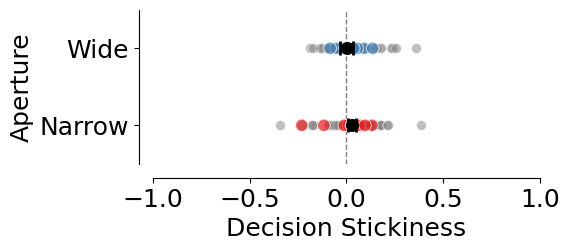

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
    plot_bias=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_decision_stickiness.svg", transparent=True)

4.3: mean=0.025 ± 0.021
12.0-4.3: TtestResult(statistic=0.33022887730553935, pvalue=0.7428686453554969, df=42)
12.0: mean=0.033 ± 0.018
4.3 vs chance 0: t=1.20, p=0.239
12.0 vs chance 0: t=1.81, p=0.078


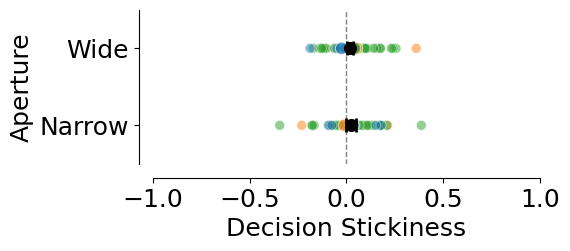

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    plot_bias=True,
    per_lab=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_decision_stickiness_per_lab.svg", transparent=True)

1.4416126369972653
mean 4.3: 1.5571415279656475
sem 4.3: 0.03398929848536531
12.0-4.3: TtestResult(statistic=-6.84696552443165, pvalue=2.406800271755431e-08, df=42)
mean 12.0: 1.3282372799864832
sem 12.0: 0.014397048738312665


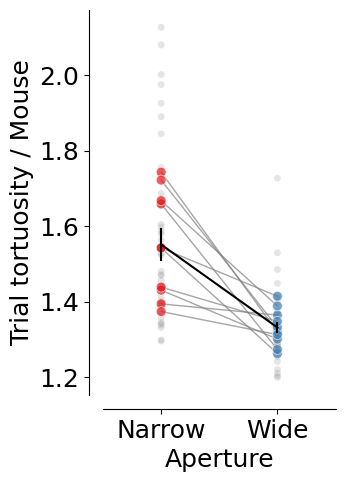

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

print(counts.groupby(["mouse_name", "aperture"]).mean(numeric_only=True).trial_tortuosity.mean())

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Trial tortuosity / Mouse")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["trial_tortuosity"],
                counts[counts["aperture"] == j]["trial_tortuosity"],
            )
            print(f"{i}-{j}: {stat}")
            
    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['trial_tortuosity'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['trial_tortuosity'])}")
plt.savefig(save_fig_path + "figure3_trial_tortuosity.svg", transparent=True)

Overall mean:  0.9726391912406422 0.005397079754695891


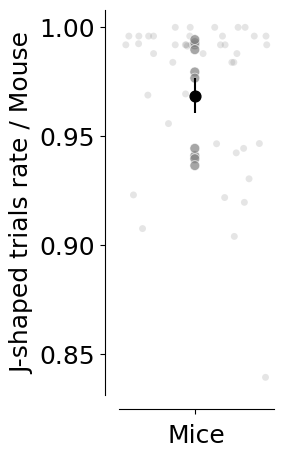

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(2, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset"], as_index=False)
    .trial_jshaped.mean()
)

counts["count"] = counts["trial_jshaped"]
counts = pd.DataFrame(counts.reset_index())

plotting._plot_bar_counts(
    counts=counts,
    label_x=None,
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=["grey"],
)

ax.set_ylabel("J-shaped trials rate / Mouse")
ax.set_xlabel("Mice")
plt.legend([], [], frameon=False)
sns.despine(offset=10)

print(f"Overall mean: ", np.mean(counts['trial_jshaped']), stats.sem(counts['trial_jshaped']))
plt.savefig(save_fig_path + "figure3_trial_jshaped.svg", transparent=True)

## Trajectory analysis

In [32]:
xy_df = []
for m in sessions_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

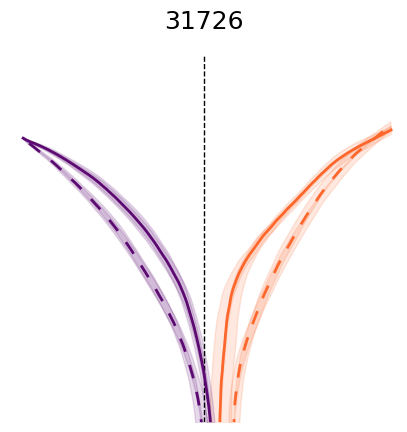

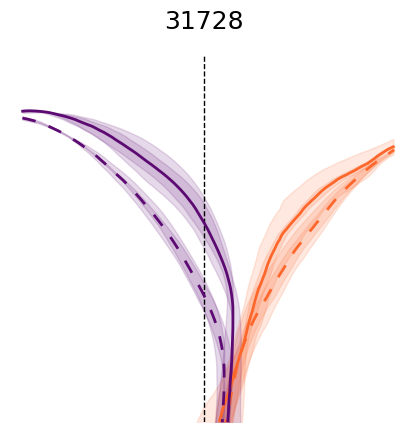

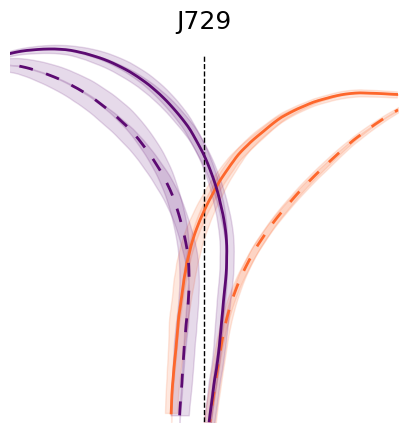

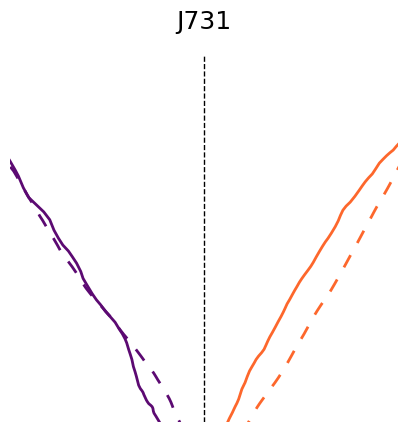

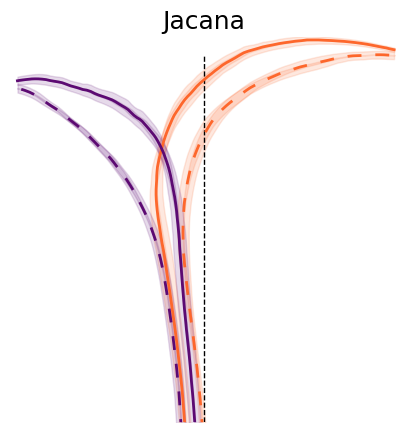

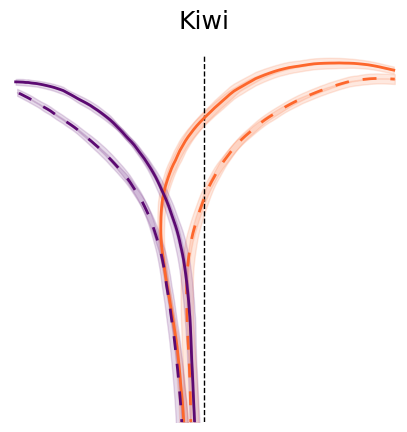

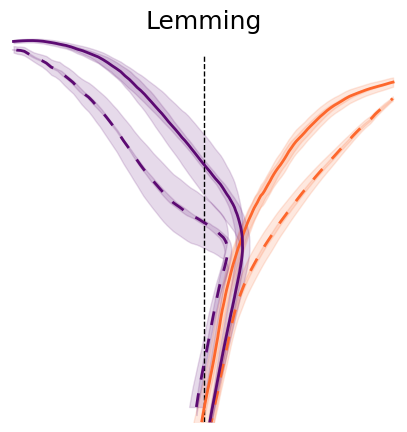

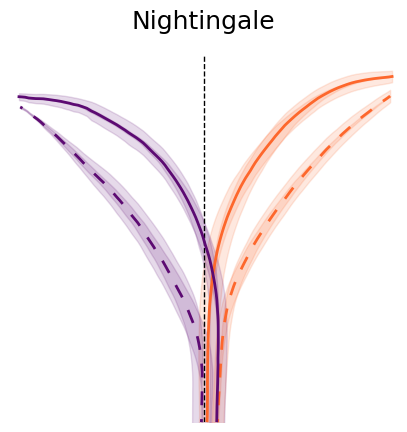

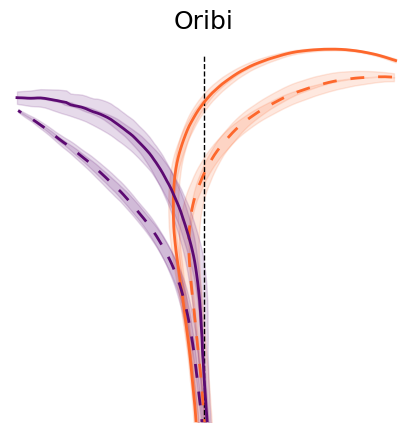

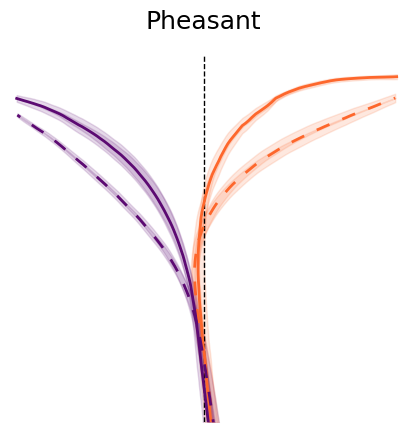

In [33]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], 
                                     cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure3_dual_occluders_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure3_dual_occluders_trajectories_time_{m}.png", transparent=True, dpi=300)

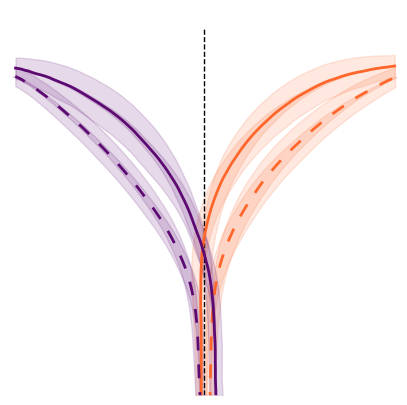

In [34]:
# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_mouse, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories from 0, 23 cm in y axis, -18, 18 cm in x axis, colored by choice and styled by aperture
plotting.plot_mean_xy_trajectory(mean_group, cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")

plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.svg", transparent=True)
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.png", transparent=True, dpi=300)

In [35]:
# Takes time
y_binned_df = []
for m in sessions_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [36]:
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture              81.0445  1.0000  42.0000 0.0000
bin_centers          177.8661 23.0000 966.0000 0.0000
aperture:bin_centers  14.5573 23.0000 966.0000 0.0000



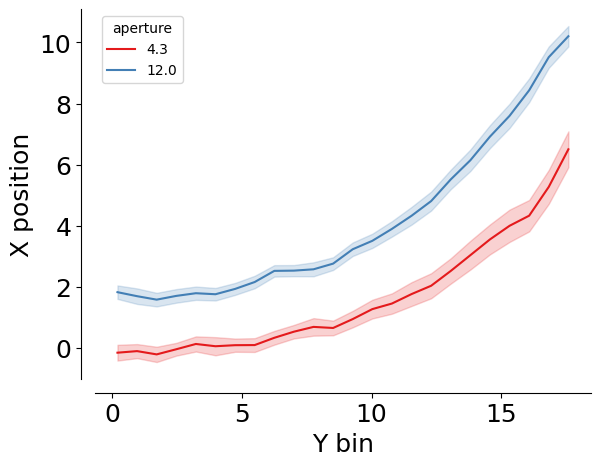

In [37]:
# NOTE(celia): Data unbalanced across bins, so only include bins so that balanced
stats_binned = y_binned_df[(y_binned_df.bin_centers >= 0) & (y_binned_df.bin_centers <= 18)]

sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y bin")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_mean_xy_trajectory.svg", transparent=True)

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [38]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

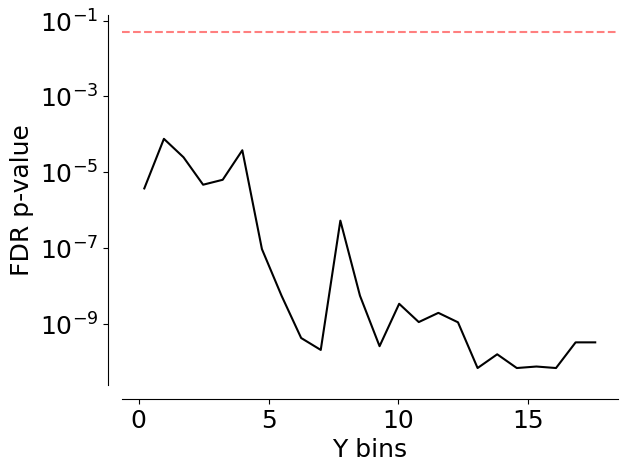

In [39]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_position_p_values.svg", transparent=True)

## Velocity analysis

In [40]:
velocity_df = []
for m in sessions_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


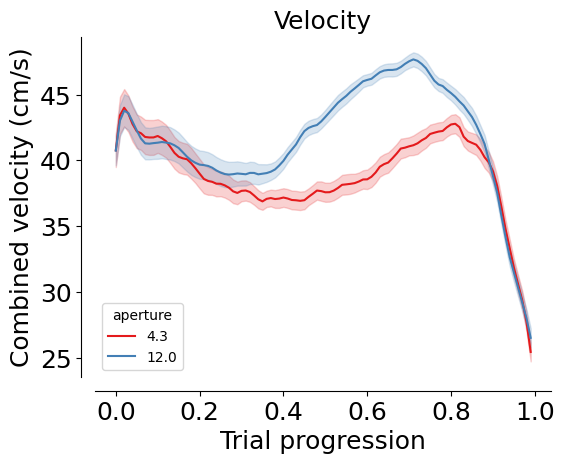

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_mean_velocity.svg", transparent=True)

In [42]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              58.3587  1.0000   42.0000 0.0000
trial_length          48.1771 99.0000 4158.0000 0.0000
aperture:trial_length 35.6148 99.0000 4158.0000 0.0000



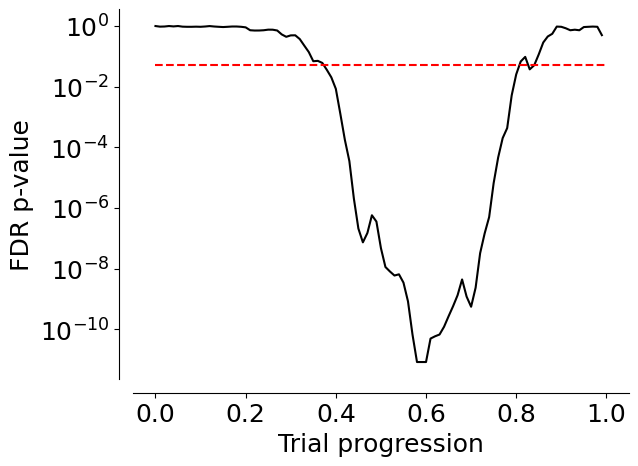

In [43]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")
plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_velocity_pvalue.svg", transparent=True)

## Optimal *p* analysis

In [44]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in sessions_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


In [45]:
optimal_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

mean 4.3: 16.68074650757546
sem 4.3: 0.5847446520330697
12.0-4.3: TtestResult(statistic=-7.120539017587505, pvalue=9.778669408258212e-09, df=42)
mean 12.0: 14.531560352042346
sem 12.0: 0.48556293421850705


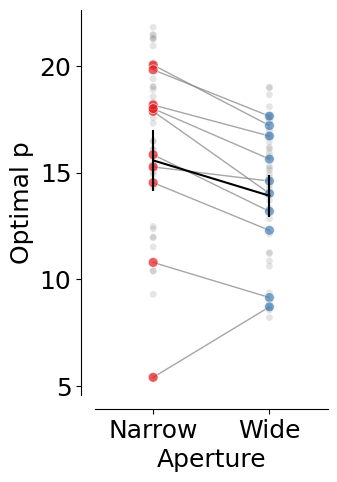

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['optimal_p'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['optimal_p'])}")
plt.savefig(save_fig_path + "figure3_fitted_p.svg", transparent=True)

12.0-4.3: TtestResult(statistic=-7.120539017587505, pvalue=9.778669408258212e-09, df=42)


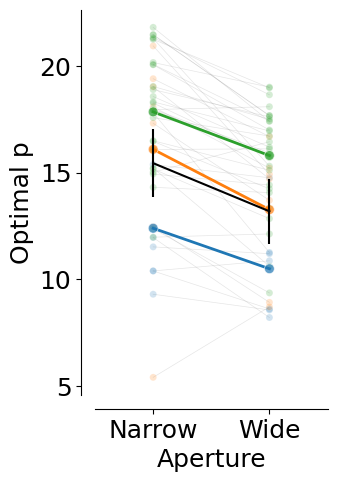

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture", "lab_id"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

plt.savefig(save_fig_path + "figure3_fitted_p_per_lab.svg", transparent=True)

In [48]:
counts.groupby("aperture").optimal_p.mean(), counts.groupby("aperture").optimal_p.sem()

(aperture
 12.0    14.531560
 4.3     16.680747
 Name: optimal_p, dtype: float64,
 aperture
 12.0    0.485563
 4.3     0.584745
 Name: optimal_p, dtype: float64)